In [42]:
import sys, os
sys.path.insert(0, "./src")

from unfold.tools.Unfolder_rho import Unfolder
from unfold.utils.merge_helpers import *
import pickle as pkl
from unfold.tools.io import load_pkls

In [51]:
out_data, out_mc = load_pkls("./inputs/rho/jms_dataV2_2016APV_syst.pkl", "./inputs/rho/jms_pythiaV2_2016APV_syst.pkl")

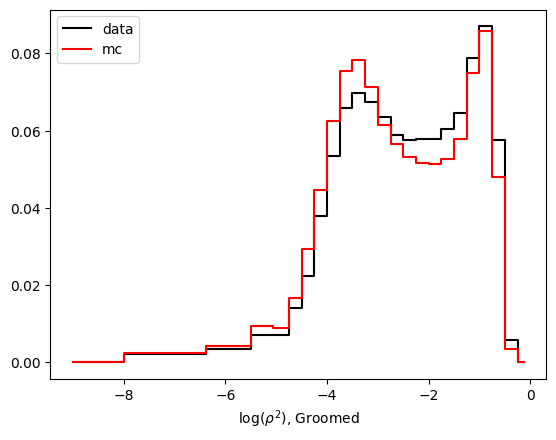

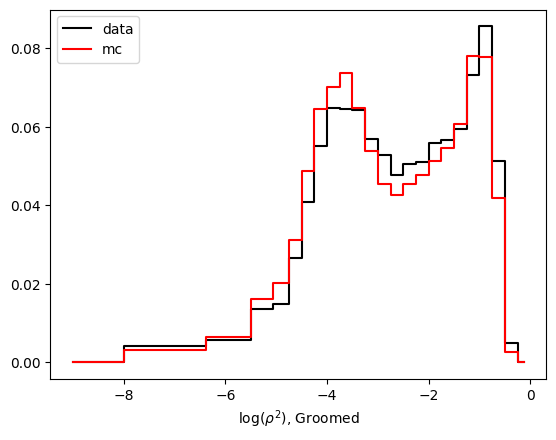

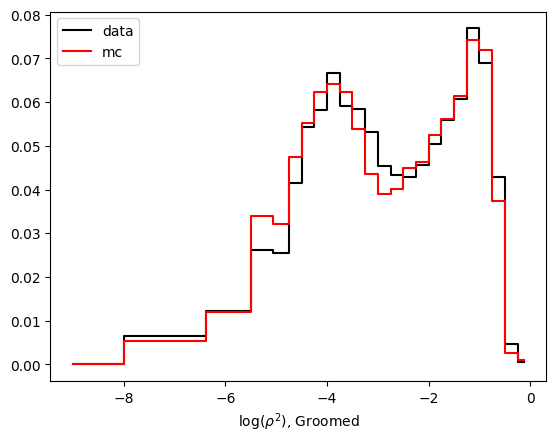

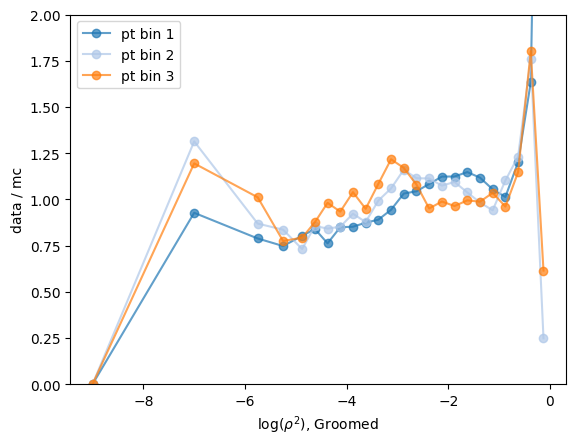

In [52]:
import numpy as np
ratio_store = []
for i in range(1,4):
    import matplotlib.pyplot as plt

    h_data = out_data["ptjet_rhojet_g_reco"].project("ptreco","mpt_reco")[i, :]
    h_mc   = out_mc["ptjet_rhojet_g_reco"].project("ptreco","mpt_reco")[i, :]

    data_vals = np.asarray(h_data.values())
    mc_vals = np.asarray(h_mc.values())

    edges = h_data.axes[0].edges
    centers = 0.5*(edges[:-1] + edges[1:])

    

    # plot ratio on a second y-axis
    main_ax = plt.gca()

    # normalize by sum
    dsum = data_vals.sum()
    msum = mc_vals.sum()
    if dsum != 0:
        data_vals = data_vals / dsum
    if msum != 0:
        mc_vals = mc_vals / msum

    plt.gca().step(centers, data_vals, where='mid', label="data", color="black")
    plt.gca().step(centers, mc_vals, where='mid', label="mc", color="red")

    # separate figure for the ratio
    fig2, ax2 = plt.subplots()
    ax2.set_xlabel(r"$\log(\rho^2)$, Groomed")
    ax2.set_ylabel("data / mc")

    # return focus to the main axes so subsequent plotting (e.g. response) uses it
    plt.sca(main_ax)

    # reuse a single ratio figure/axis for all iterations so all ratios are overlaid
    if 'shared_ratio_ax' not in globals():
        shared_ratio_fig = fig2
        shared_ratio_ax = ax2
    else:
        plt.close(fig2)            # close the extra figure just created this iteration
        fig2 = shared_ratio_fig
        ax2 = shared_ratio_ax
    ratio = np.divide(data_vals, mc_vals, out=np.zeros_like(data_vals, dtype=float), where=mc_vals!=0)
    ratio_store.append(ratio)
    #ax2.plot(centers, ratio, marker='o', color='green', label="data/mc", alpha=0.7)
    #ax2.set_ylabel("data / mc")
    #out_mc["response_matrix_rho_g"].project("ptreco","mpt_reco")[i, :].plot(label="Response projection", color="blue", ls = '--', alpha = 0.5, density = True)
    plt.xlabel(r"$\log(\rho^2)$, Groomed")
    import matplotlib.pyplot as plt
    plt.legend()
    plt.show()
# plot all ratios together
fig3, ax3 = plt.subplots()
ax3.set_xlabel(r"$\log(\rho^2)$, Groomed")
ax3.set_ylabel("data / mc")
for i, ratio in enumerate(ratio_store):
    ax3.plot(centers, ratio, marker='o', label=f"pt bin {i+1}", alpha=0.7)
plt.ylim(0, 2)
plt.legend()
plt.show()

In [33]:
print("data total ", out_data["ptjet_rhojet_g_reco"].sum())
print("mc total ", out_mc["ptjet_rhojet_g_reco"].sum())
print("mc total ", out_mc["response_matrix_rho_g"].sum())

data total  WeightedSum(value=126342, variance=126342)
mc total  WeightedSum(value=66846.9, variance=8671.34)
mc total  WeightedSum(value=65978.6, variance=8589.21)
